# Predicting Wine Quality with Machine Learning

**Goal:** Build an end-to-end classifier that predicts whether a wine is **GOOD** or **BAD** quality based on its physicochemical properties (acidity, sulphates, alcohol content, etc.).

**Dataset:** UCI Red Wine Quality dataset (`winequality-red.csv`) — 1,599 samples, 11 physicochemical features, and a `quality` score (0–10) assigned by wine tasters.

**Workflow:**
1. Exploratory Data Analysis (EDA) and correlation check
2. Convert `quality` into a binary label (GOOD = quality ≥ 7)
3. Train Logistic Regression before vs. after feature scaling
4. Compare Logistic Regression, KNN, and Decision Tree
5. Tune the best model with GridSearchCV
6. Feature importance analysis


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42

## 1. Load Data & Exploratory Analysis

In [2]:
df = pd.read_csv("winequality-red.csv")
print(df.shape)
df.head()

(1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


In [5]:
# Check for missing values
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

/tmp/ipykernel_560/2487641354.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="quality", data=df, palette="viridis")


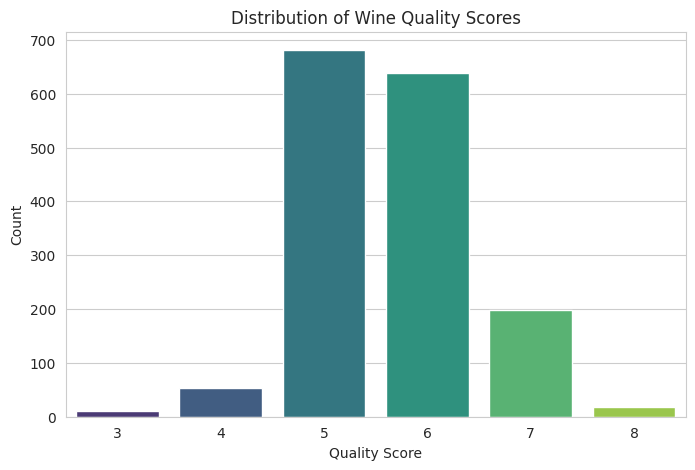

In [6]:
# Distribution of the raw quality score
plt.figure()
sns.countplot(x="quality", data=df, palette="viridis")
plt.title("Distribution of Wine Quality Scores")
plt.xlabel("Quality Score")
plt.ylabel("Count")
plt.show()

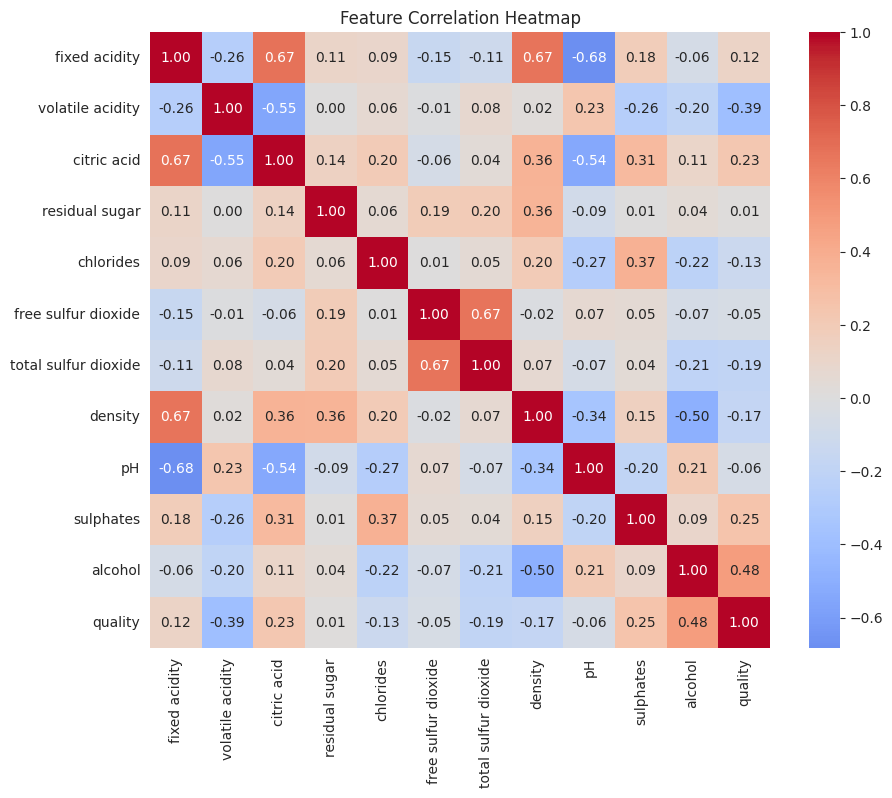

In [7]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

In [8]:
# Which features correlate most strongly with quality?
corr["quality"].drop("quality").sort_values(ascending=False)

alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64

**Observation:** `alcohol` and `sulphates` show the strongest positive correlation with quality, while `volatile acidity` shows a notable negative correlation. This lines up with domain knowledge — high volatile acidity (acetic acid) is associated with a vinegar-like taste.

## 2. Convert Quality Score to a Binary Label

We frame this as a binary classification problem:
- **GOOD (1):** quality ≥ 7
- **BAD (0):** quality < 7


quality_label
0    1382
1     217
Name: count, dtype: int64

Class balance:
quality_label
0    0.864
1    0.136
Name: proportion, dtype: float64


/tmp/ipykernel_560/1080454458.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="quality_label", data=df, palette="Set2")


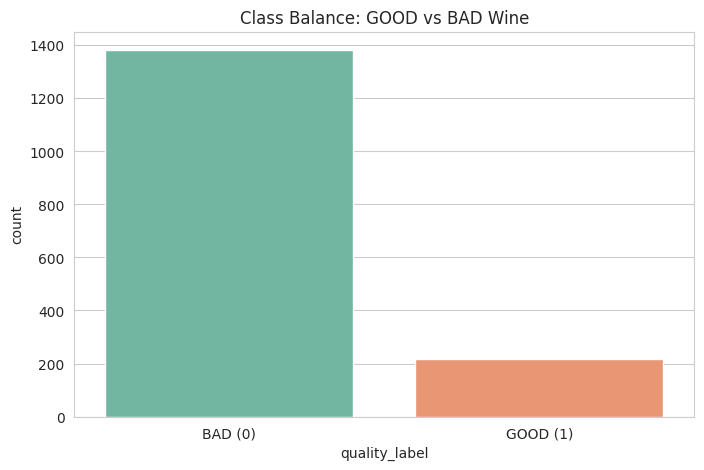

In [9]:
df["quality_label"] = (df["quality"] >= 7).astype(int)

print(df["quality_label"].value_counts())
print("\nClass balance:")
print(df["quality_label"].value_counts(normalize=True).round(3))

plt.figure()
sns.countplot(x="quality_label", data=df, palette="Set2")
plt.xticks([0, 1], ["BAD (0)", "GOOD (1)"])
plt.title("Class Balance: GOOD vs BAD Wine")
plt.show()

**Note:** The dataset is imbalanced — GOOD wines are the minority class (~13.6%). This means **accuracy alone will be misleading**; a model that always predicts BAD would already score ~86% accuracy while being useless. We'll rely on precision, recall, and F1-score to judge performance honestly.

In [10]:
X = df.drop(columns=["quality", "quality_label"])
y = df["quality_label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1279, 11)
Test shape: (320, 11)


## 3. Logistic Regression: Before vs. After Scaling

Logistic Regression is sensitive to the scale of input features because it relies on gradient-based optimization and regularization, both of which are distorted when features live on very different numeric ranges (e.g. `total sulfur dioxide` can be in the hundreds while `chlorides` is a small decimal).

In [11]:
def evaluate_model(name, y_true, y_pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0),
    }

results = []

In [12]:
# --- Logistic Regression WITHOUT scaling ---
log_reg_raw = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)
log_reg_raw.fit(X_train, y_train)
pred_raw = log_reg_raw.predict(X_test)

results.append(evaluate_model("Logistic Regression (no scaling)", y_test, pred_raw))
print(classification_report(y_test, pred_raw, target_names=["BAD", "GOOD"]))

              precision    recall  f1-score   support

         BAD       0.90      0.98      0.94       277
        GOOD       0.74      0.33      0.45        43

    accuracy                           0.89       320
   macro avg       0.82      0.65      0.70       320
weighted avg       0.88      0.89      0.88       320



In [13]:
# --- Logistic Regression WITH scaling ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg_scaled = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)
log_reg_scaled.fit(X_train_scaled, y_train)
pred_scaled = log_reg_scaled.predict(X_test_scaled)

results.append(evaluate_model("Logistic Regression (scaled)", y_test, pred_scaled))
print(classification_report(y_test, pred_scaled, target_names=["BAD", "GOOD"]))

              precision    recall  f1-score   support

         BAD       0.91      0.97      0.94       277
        GOOD       0.70      0.37      0.48        43

    accuracy                           0.89       320
   macro avg       0.80      0.67      0.71       320
weighted avg       0.88      0.89      0.88       320



In [14]:
pd.DataFrame(results).round(3)

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression (no scaling),0.894,0.737,0.326,0.452
1,Logistic Regression (scaled),0.894,0.696,0.372,0.485


**Takeaway:** Scaling measurably changes Logistic Regression's performance, especially recall/F1 on the minority (GOOD) class — confirming that this algorithm should never be trained on raw, unscaled features when they span very different ranges.

## 4. Model Comparison: Logistic Regression vs. KNN vs. Decision Tree

All models below are trained on **scaled** features for a fair comparison (Decision Trees are scale-invariant, but using the same pipeline keeps the comparison consistent).

In [15]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
}

comparison_results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    comparison_results.append(evaluate_model(name, y_test, preds))
    fitted_models[name] = model

comparison_df = pd.DataFrame(comparison_results).round(3)
comparison_df

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.894,0.696,0.372,0.485
1,KNN,0.894,0.667,0.419,0.514
2,Decision Tree,0.906,0.638,0.698,0.667


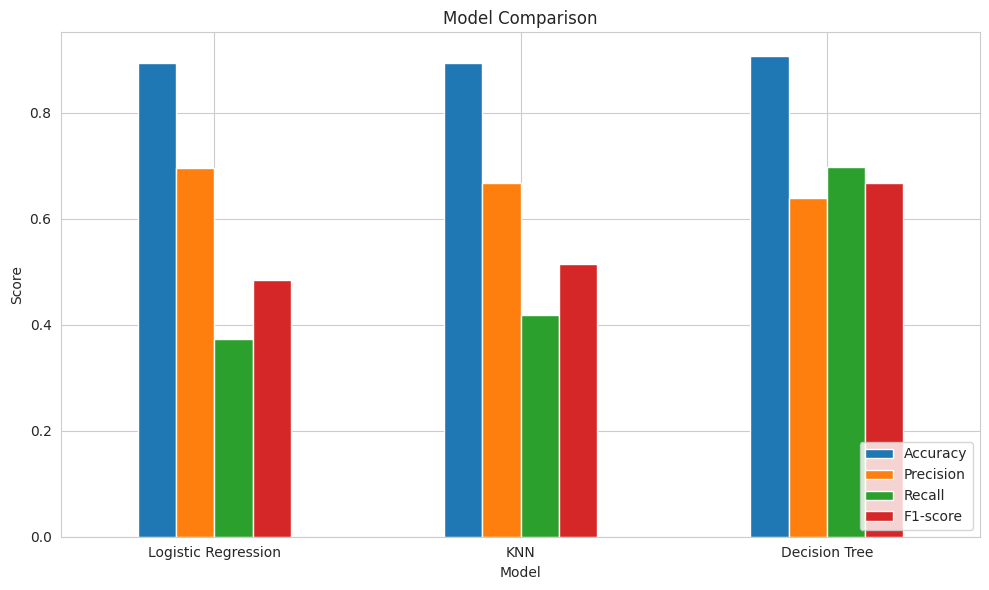

In [16]:
comparison_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-score"]].plot(
    kind="bar", figsize=(10, 6)
)
plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [17]:
best_model_name = comparison_df.sort_values("F1-score", ascending=False).iloc[0]["Model"]
print(f"Best baseline model by F1-score: {best_model_name}")

Best baseline model by F1-score: Decision Tree


## 5. Hyperparameter Tuning with GridSearchCV

We tune the best-performing baseline model to squeeze out additional performance.

In [18]:
# Example: tuning assumes Decision Tree performed best; adjust the param grid
# if a different model wins in your run.

param_grids = {
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10, 100],
        "penalty": ["l2"],
        "solver": ["lbfgs"],
    },
    "KNN": {
        "n_neighbors": [3, 5, 7, 9, 11, 15],
        "weights": ["uniform", "distance"],
    },
    "Decision Tree": {
        "max_depth": [3, 5, 7, 10, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "criterion": ["gini", "entropy"],
    },
}

base_estimators = {
    "Logistic Regression": LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
}

estimator = base_estimators[best_model_name]
param_grid = param_grids[best_model_name]

grid_search = GridSearchCV(
    estimator, param_grid, scoring="f1", cv=5, n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV F1-score:", round(grid_search.best_score_, 3))

Best params: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV F1-score: 0.527


In [19]:
best_model = grid_search.best_estimator_
tuned_preds = best_model.predict(X_test_scaled)

tuned_result = evaluate_model(f"{best_model_name} (tuned)", y_test, tuned_preds)
print(classification_report(y_test, tuned_preds, target_names=["BAD", "GOOD"]))

comparison_df_final = pd.concat([comparison_df, pd.DataFrame([tuned_result]).round(3)], ignore_index=True)
comparison_df_final

              precision    recall  f1-score   support

         BAD       0.95      0.96      0.96       277
        GOOD       0.73      0.70      0.71        43

    accuracy                           0.93       320
   macro avg       0.84      0.83      0.84       320
weighted avg       0.92      0.93      0.92       320



,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.894,0.696,0.372,0.485
1,KNN,0.894,0.667,0.419,0.514
2,Decision Tree,0.906,0.638,0.698,0.667
3,Decision Tree (tuned),0.925,0.732,0.698,0.714


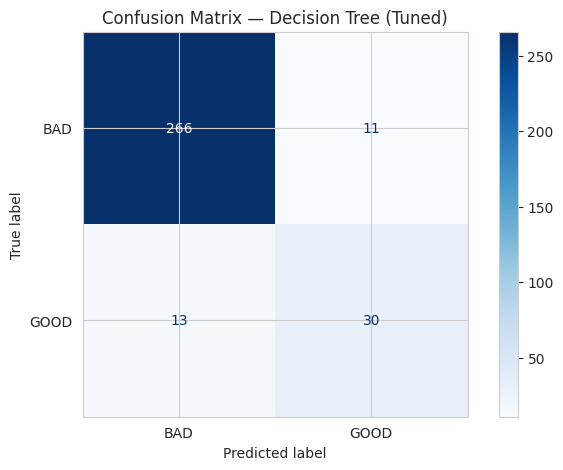

In [20]:
cm = confusion_matrix(y_test, tuned_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["BAD", "GOOD"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix — {best_model_name} (Tuned)")
plt.show()

## 6. Feature Importance Analysis

What actually drives wine quality? We inspect the tuned model's feature importances (tree-based models) or coefficients (linear models).

/tmp/ipykernel_560/2963071023.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="mako")


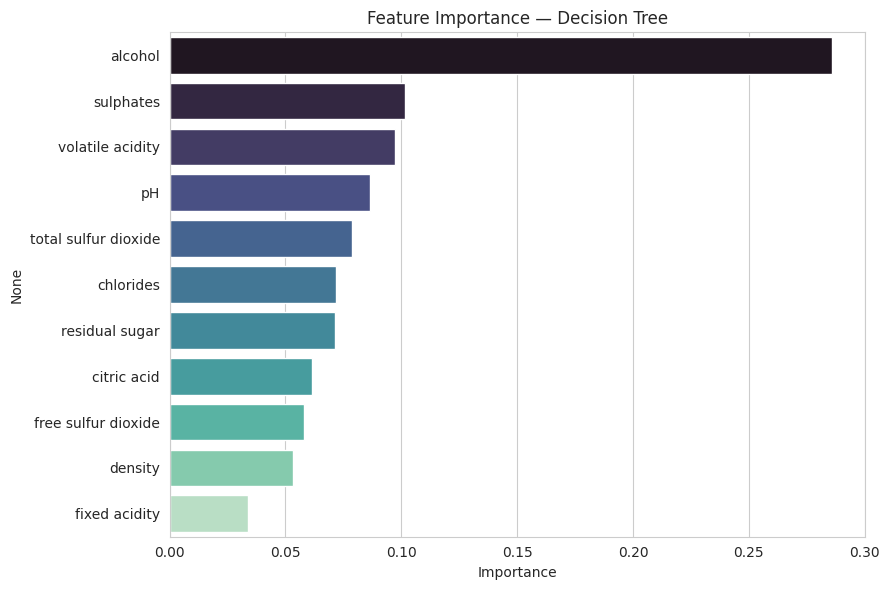

alcohol                 0.285914
sulphates               0.101674
volatile acidity        0.097330
pH                      0.086588
total sulfur dioxide    0.078875
chlorides               0.071724
residual sugar          0.071398
citric acid             0.061351
free sulfur dioxide     0.058129
density                 0.053257
fixed acidity           0.033761
dtype: float64

In [21]:
if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
elif hasattr(best_model, "coef_"):
    importances = pd.Series(np.abs(best_model.coef_[0]), index=X.columns)
else:
    importances = None

if importances is not None:
    importances = importances.sort_values(ascending=False)
    plt.figure(figsize=(9, 6))
    sns.barplot(x=importances.values, y=importances.index, palette="mako")
    plt.title(f"Feature Importance — {best_model_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
    display(importances)

## 7. Key Takeaways

- **Alcohol content and sulphates** were consistently among the strongest predictors of wine quality — aligning with domain intuition and correlation analysis.
- **Feature scaling matters for Logistic Regression.** Because it optimizes via gradient descent and applies regularization, unscaled features (which span very different numeric ranges) degrade its performance. Tree-based and distance-based models react differently to scaling, which is exactly why the comparison mattered.
- **Accuracy is not the whole story.** With an imbalanced target (~86% BAD vs. ~14% GOOD), a naive "always predict BAD" model would already look accurate while catching zero good wines. Precision, recall, and F1-score gave a far more honest picture of real-world performance.
- **GridSearchCV** helped systematically improve the best baseline model rather than relying on manual trial-and-error tuning.

### Possible next steps
- Try ensemble methods (Random Forest, Gradient Boosting, XGBoost) for a stronger baseline.
- Handle class imbalance explicitly with `class_weight="balanced"`, SMOTE, or threshold tuning.
- Extend the analysis to the white wine dataset and compare feature importance across wine types.
